# Car Suspension Dynamics — Spring-Damper System Analysis
## AMME2500 Engineering Dynamics — Major Assignment

---

| | |
|:---|:---|
| **Name** | **SID** | **Contribution** |
| Isaac Edmonds | 550813846 | [one-line contribution statement] |
| Naimish Aggarwal | 550725262 | [one-line contribution statement] |
| [Name 3] | [xxxxxxxxx] | [one-line contribution statement] |

**Date Submitted:** 29th May 2026

## Abstract

*A brief summary of the method, results, and conclusions (typically 150–200 words).*

[Describe: (1) the system modelled and its governing physics, (2) the numerical method used to solve the equations of motion, (3) the key quantitative results obtained, and (4) the main engineering conclusions drawn from the analysis.]

## Declaration of Generative AI Use

- GitHub Copilot was used for autocomplete suggestions when writing numerical integration code.
- Claude was used for structuring jupyter notebook in a visually appealing way.

## 1. Introduction

<!-- *Outline the system being investigated, its novelty, the motivation, aims, and structure of the report.*

[Describe the car suspension spring-damper system — what it is, why it is an interesting and practically relevant mechanical system to study, what gaps or questions this investigation addresses, the specific aims of the report, and how the rest of the report is organised.] -->

This report is an investigation into car suspension systems. We aim to determine the effectiveness of different suspension systems by finding a meaningful correlation between dampening and spring coefficients, and the safety of the passengers. To do this we have made a computational model of our system. Our model represents the main body of the car as a beam suspended by two different spring and dampener systems on either side. There are also two passengers in the system who are substituted for two pendulums with a torsion spring to simulate the human tendency to sit upright. This system is mechanically interesting as it extends the dampened spring and pendulum systems seen throughout the semester with further ridged body dynamics.

Our report contains a detailed methodology that describes in detail the mathematical derivation of our equations of motion from the base system. We extrapolate these findings further with an outline of the computational method that will be completed throughout the report. Our code is broken up into three major sections; definition of variables and equations, solving of equations, and the extraction of useful data, later shown through diagrams. Finally, our findings are discussed at length in the results section.

Throughout this investigation in ridged body dynamics, we hope to better understand the vital safety mechanisms within all our cars.


## 2. Methodology

### 2.1 System Description & Free Body Diagram

Initially, the people can be considered to be point masses on the car, and hence the Free Body Diagram of the dynamic forces on the car is as shown below in Figure 

![Main FBD](./pic/MAIN_FBD.jpeg)

### 2.2 Equations of Motion

*Derive or present the governing ODEs here. Use LaTeX for equations, e.g.:*

$$m\ddot{x} + c\dot{x} + kx = F(t)$$

### 2.3 Computational Approach

*Describe the numerical integration method used (e.g. `solve_ivp` with RK45), step-size selection, solver tolerances, etc.*

### 2.4 Initial & Boundary Conditions

| Parameter | Symbol | Value | Units |
|:----------|:------:|------:|:-----:|
| [param]   | [sym]  | [val] | [unit]|

### 2.5 Validation & Convergence

*Demonstrate that the solver converges and produces physically consistent results (e.g. energy conservation checks, comparison against an analytical limit case, step-size sensitivity).*

---
### Code & Implementation

load libraries

In [1310]:
import numpy as np
import sympy as sp
from sympy.physics.mechanics import dynamicsymbols
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pandas as pd
import IPython.display as disp
import pygame
import sys
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

In [1311]:
#global constants
g = 9.81

t = sp.symbols('t')

Optimisation variables:

In [1312]:
x = dynamicsymbols('x')
theta = dynamicsymbols('theta')
beta_a = dynamicsymbols('beta_a')
beta_b = dynamicsymbols('beta_b')

First derivative:

In [1313]:
x_d = sp.diff(x, t)
theta_d = sp.diff(theta, t)
beta_a_d = sp.diff(beta_a, t)
beta_b_d = sp.diff(beta_b, t)

second derivative:

In [1314]:
x_dd = sp.diff(x, t, 2)
theta_dd = sp.diff(theta, t, 2)
beta_a_dd = sp.diff(beta_a, t, 2)
beta_b_dd = sp.diff(beta_b, t, 2)

Parameters:

In [1315]:
m_car, I_car, L_car, k, c, A_road, wavelength_road, v_road, h0, R_wheel, I_person, k_torsion, c_torsion = sp.symbols(
    'm_c I_c L_c k_c c_c A_r lamda_r v_r h0 R I_p k_t c_t')

x_a = -L_car / 2
x_b = L_car / 2

Road equation:

In [1316]:
def road_sym(x_wheel):
    return A_road * sp.sin(2 * sp.pi * (v_road*t + x_wheel) / wavelength_road)

finding F in a and b:

In [1317]:
road_h_a  = road_sym(x_a)
road_h_b = road_sym(x_b)

wheel_center_a  = road_h_a + R_wheel
wheel_center_b = road_h_b + R_wheel

car_h_a  = h0 + x + x_a  * theta
car_h_b = h0 + x + x_b * theta

l0 = h0 - R_wheel

def suspension_force(z_body, z_wheel):
    s = z_body - z_wheel
    s_d = sp.diff(s, t)
    return -k * (s - l0) - c * s_d

F_left  = suspension_force(car_h_a,  wheel_center_a)
F_right = suspension_force(car_h_b, wheel_center_b)

T_a_on_car = k_torsion * (beta_a - theta) + c_torsion * (beta_a_d - theta_d)
T_b_on_car = k_torsion * (beta_b - theta) + c_torsion * (beta_b_d - theta_d)

a and b equation:

In [1318]:
rod_a_eq = sp.Eq(I_person * beta_a_dd, -k_torsion * (beta_a - theta) - c_torsion * (beta_a_d - theta_d))

rod_b_eq = sp.Eq(I_person * beta_b_dd, -k_torsion * (beta_b - theta) - c_torsion * (beta_b_d - theta_d))

get solution:

In [1319]:
moment_suspension = x_a * F_left + x_b * F_right
moment_people = T_a_on_car + T_b_on_car

vertical_eq = sp.Eq(m_car * x_dd, F_left + F_right)

pitch_eq = sp.Eq(
    I_car * theta_dd,
    moment_suspension + moment_people
)

solu_vert = sp.solve(vertical_eq, x_dd, simplify=True)[0]
solu_theta = sp.solve(pitch_eq, theta_dd, simplify=True)[0]
solu_beta_a = sp.solve(rod_a_eq, beta_a_dd, simplify=True)[0]
solu_beta_b = sp.solve(rod_b_eq, beta_b_dd, simplify=True)[0]

disp.display(solu_vert)
disp.display(solu_theta)
disp.display(solu_beta_a)
disp.display(solu_beta_b)

(4*pi*A_r*c_c*v_r*(1 - 2*sin(pi*t*v_r/lamda_r)**2)*cos(pi*L_c/lamda_r) + lamda_r*(-A_r*k_c*sin(pi*(L_c - 2*t*v_r)/lamda_r) + A_r*k_c*sin(pi*(L_c + 2*t*v_r)/lamda_r) - 2*c_c*Derivative(x(t), t) - 2*k_c*x(t)))/(lamda_r*m_c)

(pi*A_r*L_c*c_c*v_r*(-cos(pi*(L_c - 2*t*v_r)/lamda_r) + cos(pi*(L_c + 2*t*v_r)/lamda_r)) + lamda_r*(A_r*L_c*k_c*sin(pi*(L_c - 2*t*v_r)/lamda_r) + A_r*L_c*k_c*sin(pi*(L_c + 2*t*v_r)/lamda_r) - L_c**2*c_c*Derivative(theta(t), t) - L_c**2*k_c*theta(t) + 2*c_t*Derivative(beta_a(t), t) + 2*c_t*Derivative(beta_b(t), t) - 4*c_t*Derivative(theta(t), t) + 2*k_t*beta_a(t) + 2*k_t*beta_b(t) - 4*k_t*theta(t))/2)/(I_c*lamda_r)

(-c_t*Derivative(beta_a(t), t) + c_t*Derivative(theta(t), t) - k_t*beta_a(t) + k_t*theta(t))/I_p

(-c_t*Derivative(beta_b(t), t) + c_t*Derivative(theta(t), t) - k_t*beta_b(t) + k_t*theta(t))/I_p

lambdify:

In [1320]:
x_lamb, xd_lamb, xdd_lamb, theta_lamb, theta_d_lamb, beta_a_lamb, beta_a_d_lamb, beta_b_lamb, beta_b_d_lamb, time_lamb = sp.symbols(
    'x xd xdd theta theta_d beta_a beta_a_d beta_b beta_b_d t')

subs_dict = {
    x: x_lamb,
    x_d: xd_lamb,
    theta: theta_lamb,
    theta_d: theta_d_lamb,
    beta_a: beta_a_lamb,
    beta_a_d: beta_a_d_lamb,
    beta_b: beta_b_lamb,
    beta_b_d: beta_b_d_lamb,
    t: time_lamb
}

q_dd_expr = solu_vert.subs(subs_dict)
theta_dd_expr = solu_theta.subs(subs_dict)
beta_a_dd_expr = solu_beta_a.subs(subs_dict)
beta_b_dd_expr = solu_beta_b.subs(subs_dict)

param_list = [time_lamb, x_lamb, xd_lamb, theta_lamb, theta_d_lamb, beta_a_lamb, beta_a_d_lamb, beta_b_lamb, beta_b_d_lamb, m_car, I_car, L_car, k, c, A_road, wavelength_road, v_road, h0, R_wheel, I_person, k_torsion, c_torsion]

acceleration_func = sp.lambdify(param_list, [q_dd_expr, theta_dd_expr, beta_a_dd_expr, beta_b_dd_expr], modules="numpy")

### Numerical caclulation:

In [1321]:
# Car
M_val = 1200.0
L_val = 2.5
I_val = (1/12) * M_val * L_val**2

# Road
A_road_val =0.025#0.05
wavelength_val =1#4.0
v_val = 5.556#5.0

# Ride height and wheel radius
h0_val = 0.30      # car body centre is 0.3 m above flat ground
Rw_val = 0.10      # wheel radius, m

# Person rods
m_p_val = 70.0
l_p_val = 1.0
I_p_val = (1/3) * m_p_val * l_p_val**2

k_tor_val = 400.0
c_tor_val = 40.0

In [1322]:
def road_height_num(t, x_wheel):
    return A_road_val * np.sin(2 * np.pi * (v_val*t + x_wheel) / wavelength_val)


def road_velocity_num(t, x_wheel):
    omega = 2 * np.pi * v_val / wavelength_val
    phase = 2 * np.pi * x_wheel / wavelength_val
    return A_road_val * omega * np.cos(omega*t + phase)

def force_limit(s, s_d):
    s_min = 0.08 #spring length limit, so the jit don't fall thru the ground
    k_stop = 200000.0
    c_stop = 8000.0

    if s < s_min:
        compression = s_min - s
        compression_speed = max(0.0, -s_d)
        return k_stop * compression + c_stop * compression_speed
    else:
        return 0.0
    
def car_system(t_num, y, k_val, c_val):
    x_val, x_d_val, theta_val, theta_d_val, beta_a_val, beta_a_d_val, beta_b_val, beta_b_d_val = y

    x_dd, theta_dd, beta_a_dd, beta_b_dd = acceleration_func(t_num, x_val, x_d_val, theta_val, theta_d_val, beta_a_val, beta_a_d_val, beta_b_val, beta_b_d_val, M_val, I_val, L_val, k_val, c_val, A_road_val, wavelength_val, v_val, h0_val, Rw_val, I_p_val, k_tor_val, c_tor_val
    )

    x_a_num = -L_val / 2
    x_b_num = L_val / 2

    s_a = h0_val + x_val + x_a_num * theta_val - road_height_num(t_num, x_a_num) + Rw_val
    s_b = h0_val + x_val + x_b_num * theta_val - road_height_num(t_num, x_b_num) + Rw_val

    s_a_d = x_d_val + x_a_num * theta_d_val - road_velocity_num(t_num, x_a_num)
    s_b_d = x_d_val + x_b_num * theta_d_val - road_velocity_num(t_num, x_b_num)

    F_stop_left = force_limit(s_a, s_a_d)
    F_stop_right = force_limit(s_b, s_b_d)

    x_dd += (F_stop_left + F_stop_right) / M_val

    moment_stop = x_a_num * F_stop_left + x_b_num * F_stop_right
    theta_dd += moment_stop / I_val

    return [x_d_val, x_dd, theta_d_val, theta_dd, beta_a_d_val, beta_a_dd, beta_b_d_val, beta_b_dd]

lambdify numerical:

In [1323]:
t_start = 0
t_end = 10
dt = 0.0001#0.01
t_vals = np.arange(t_start, t_end, dt)

# Suspension values
k_val = 42000.0
c_val = 6000.0

# Initial conditions
y0 = [
    0.0, #x
    0.0, #x_d
    0.0, #theta
    0.0, #theta_d
    0.0, #beta_a
    0.0, #beta_a_d
    0.0, #beta_b
    0.0 #beta_b_d
]

sol = solve_ivp(
    fun=lambda t, y: car_system(t, y, k_val, c_val),
    t_span=(t_start, t_end),
    y0=y0,
    t_eval=t_vals,
    method="RK45",
    max_step=0.01
)

In [1324]:
time = sol.t
x_result = sol.y[0]
theta_result = sol.y[2]
beta_a_result = sol.y[4]
beta_b_result = sol.y[6]

car_height_result = h0_val + x_result

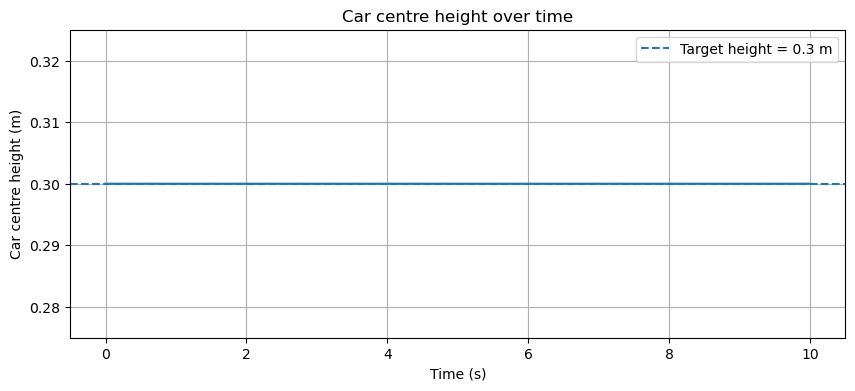

In [1333]:
plt.figure(figsize=(10, 4))
plt.plot(time, car_height_result)
plt.axhline(h0_val, linestyle="--", label="Target height = 0.3 m")
plt.xlabel("Time (s)")
plt.ylabel("Car centre height (m)")
plt.title("Car centre height over time")
plt.ylim(0.275, 0.325)
plt.legend()
plt.grid(True)
plt.savefig("Report/Images/car_height_plot.png")
plt.show()

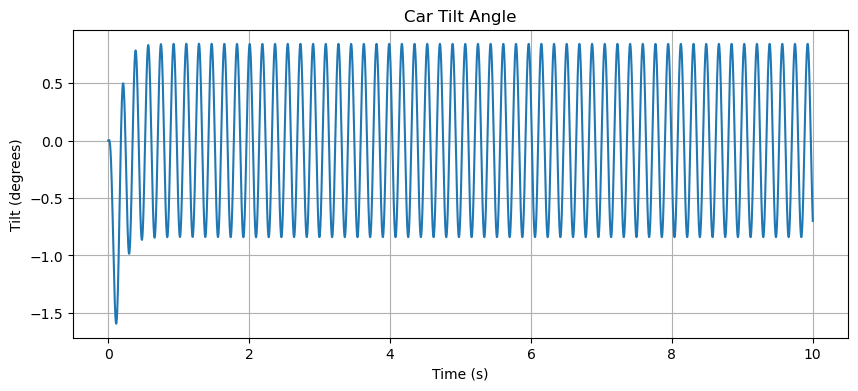

In [1326]:
plt.figure(figsize=(10, 4))
plt.plot(time, np.rad2deg(theta_result))
plt.xlabel("Time (s)")
plt.ylabel("Tilt (degrees)")
plt.title("Car Tilt Angle")
plt.grid(True)
plt.savefig("Report/Images/tilt_angle.png")
plt.show()

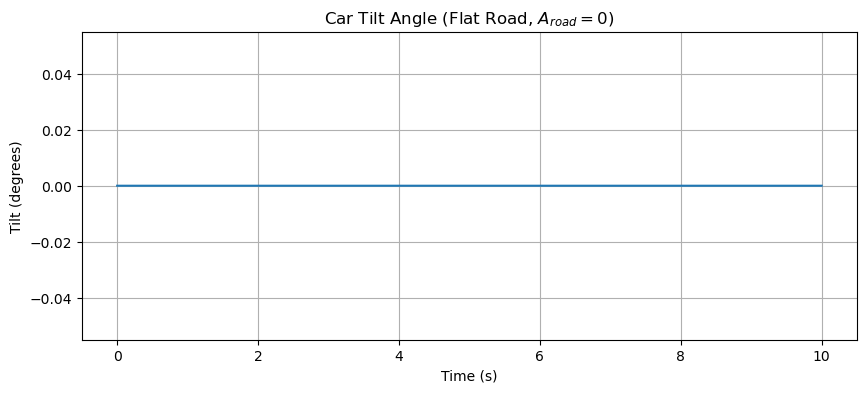

In [1327]:
# Car tilt angle on flat road (A_road = 0) — isolated, does not modify A_road_val for other cells
_saved_A_road = A_road_val
A_road_val = 0.0

sol_flat = solve_ivp(
    fun=lambda t, y: car_system(t, y, k_val, c_val),
    t_span=(t_start, t_end),
    y0=y0,
    t_eval=t_vals,
    method="RK45",
    max_step=0.01
)

A_road_val = _saved_A_road  # restore immediately

plt.figure(figsize=(10, 4))
plt.plot(sol_flat.t, np.rad2deg(sol_flat.y[2]))
plt.xlabel("Time (s)")
plt.ylabel("Tilt (degrees)")
plt.title("Car Tilt Angle (Flat Road, $A_{road} = 0$)")
plt.grid(True)
plt.savefig("Report/Images/tilt_angle_flat_road.png")
plt.show()

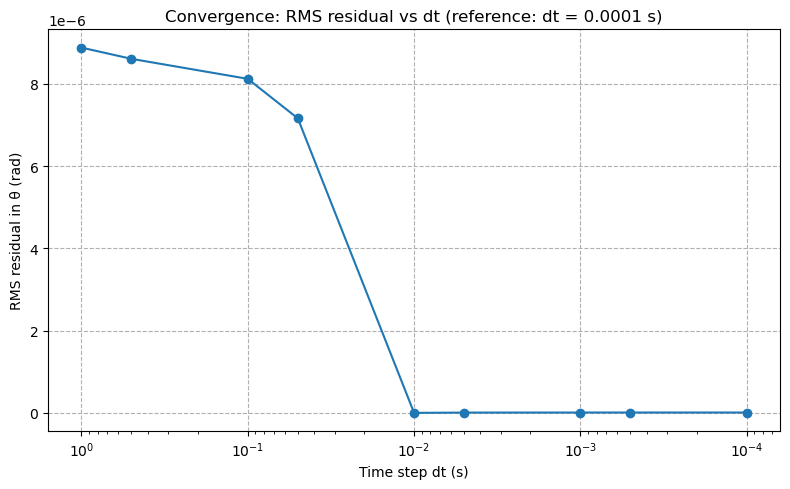

In [1328]:
dt_values = [1.0, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0.0005, 0.0001]
residuals = []

for dt_test in dt_values:
    t_test = np.arange(t_start, t_end, dt_test)
    sol_test = solve_ivp(
        fun=lambda t, y: car_system(t, y, k_val, c_val),
        t_span=(t_start, t_end),
        y0=y0,
        t_eval=t_test,
        method="RK45",
        max_step=dt_test
    )
    theta_ref_interp = np.interp(t_test, time, theta_ref)
    residual = np.sqrt(np.mean((sol_test.y[2] - theta_ref_interp) ** 2))
    residuals.append(residual)

plt.figure(figsize=(8, 5))
plt.plot(dt_values, residuals, "o-", color="tab:blue")
plt.xscale("log")
plt.gca().invert_xaxis()
plt.xlabel("Time step dt (s)")
plt.ylabel("RMS residual in θ (rad)")
plt.title("Convergence: RMS residual vs dt (reference: dt = 0.0001 s)")
plt.grid(True, linestyle="--")
plt.tight_layout()
plt.savefig("Report/Images/convergence_plot.png")
plt.show()

In [1329]:
dt = 0.01
t_vals = np.arange(t_start, t_end, dt)

k_values = np.linspace(7000,60000, 30) #(20000, 1200000, 20) #
c_values = np.linspace(500, 6000, 10) #(0, 12000, 20) #

results = []

for k_test in k_values:
    for c_test in c_values:

        sol_test = solve_ivp(
            fun=lambda t, y: car_system(t, y, k_test, c_test),
            t_span=(t_start, t_end),
            y0=y0,
            t_eval=t_vals,
            method="RK45",
            max_step=0.01
        )

        x_test = sol_test.y[0]
        theta_test = sol_test.y[2]

        max_x = np.max(np.abs(x_test))
        max_theta_deg = np.rad2deg(np.max(np.abs(theta_test)))

        results.append({
            "spring(k_N/m)": k_test,
            "damping(c_Ns/m)": c_test,
            "max_vert_displacement(m)": max_x,
            "max_tilt(deg)": max_theta_deg
        })

results_df = pd.DataFrame(results)

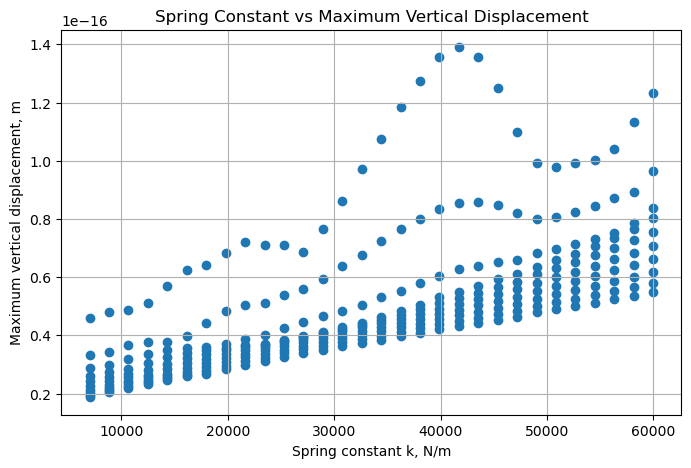

In [1330]:
plt.figure(figsize=(8, 5))
plt.scatter(
    results_df["spring(k_N/m)"],
    results_df["max_vert_displacement(m)"]
)
plt.xlabel("Spring constant k, N/m")
plt.ylabel("Maximum vertical displacement, m")
plt.title("Spring Constant vs Maximum Vertical Displacement")
plt.grid(True)
plt.savefig("Report/Images/spring_vs_displacement.png")
plt.show()

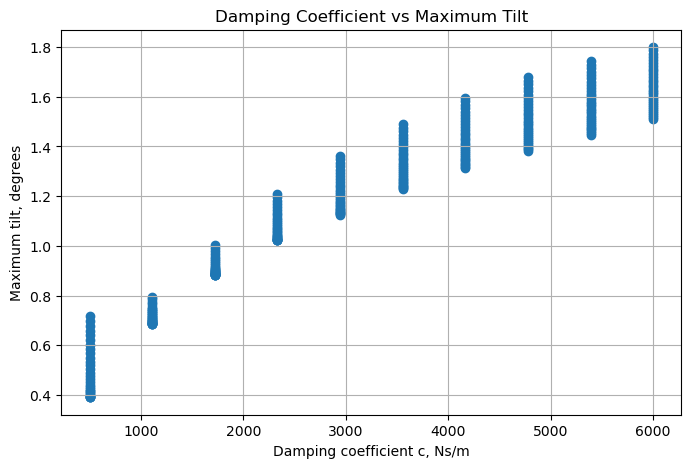

The optimal spring and damping coefficient for minimum tilt is {'spring(k_N/m)': 12482.758620689656, 'damping(c_Ns/m)': 500.0} with a maximum tilt of 0.39 degrees and maximum vertical displacement of 0.0000 m.


In [1331]:
plt.figure(figsize=(8, 5))
plt.scatter(
    results_df["damping(c_Ns/m)"],
    results_df["max_tilt(deg)"]
)
plt.xlabel("Damping coefficient c, Ns/m")
plt.ylabel("Maximum tilt, degrees")
plt.title("Damping Coefficient vs Maximum Tilt")
plt.grid(True)
plt.savefig("Report/Images/damping_vs_tilt.png")
plt.show()

print(f"The optimal spring and damping coefficient for minimum tilt is {results_df.loc[results_df['max_tilt(deg)'].idxmin(), ['spring(k_N/m)', 'damping(c_Ns/m)']].to_dict()} with a maximum tilt of {results_df['max_tilt(deg)'].min():.2f} degrees and maximum vertical displacement of {results_df.loc[results_df['max_tilt(deg)'].idxmin(), 'max_vert_displacement(m)']:.4f} m.")

In [1332]:
# from matplotlib.animation import FuncAnimation
# from IPython.display import HTML
# import matplotlib.pyplot as plt
# import numpy as np

# fig, ax = plt.subplots()

# ax.set_xlim(-2, 2)
# ax.set_ylim(-0.2, 1.0)
# ax.set_aspect("equal")

# car_line, = ax.plot([], [], "k-", linewidth=4)
# road_line, = ax.plot([], [], "b-", linewidth=2)

# info_text = ax.text(0.02,  0.95,"",  transform=ax.transAxes,  fontsize=8,  verticalalignment="top")

# def init():
#     car_line.set_data([], [])
#     road_line.set_data([], [])
#     info_text.set_text("")
#     return car_line, road_line

# def animate(i):
#     x = x_result[i]
#     theta = theta_result[i]

#     x_a = -L_val / 2
#     x_b = L_val / 2

#     y_a = h0_val + x + x_a * theta
#     y_b = h0_val + x + x_b * theta

#     car_line.set_data([x_a, x_b], [y_a, y_b])

#     xs = np.linspace(-2, 2, 200)
#     ys = road_height_num(time[i], xs)
#     road_line.set_data(xs, ys)

#     current_time = time[i]

#     info_text.set_text(
#         f"t = {current_time:.2f} s\n"
#         f"height = {h0_val + x:.3f} m\n"
#         f"x = {x:.3f} m\n"
#         f"theta = {np.rad2deg(theta):.2f} deg"
#     )


#     return car_line, road_line

# dt = time[1] - time[0]

# anim = FuncAnimation(fig, animate, frames=len(time), init_func=init, blit=False, interval=1000 * dt)

# plt.close(fig)

# HTML(anim.to_jshtml())

## 3. Results

*Present sufficient figures, tables, calculations, and discussion to analyse the system and reach conclusions.*

**Reminder:** all graphs must include axis labels with units, a legend, and a descriptive caption.

---

## 4. Conclusions

*Summary of what was done and the main scientific/engineering findings.*

[Concisely restate the aims, the approach taken, and the key quantitative/qualitative findings. Avoid introducing new material here.]

---
## Appendix

*Additional material useful but not essential to the main narrative. This section is optional.*

---
## References

*All references must be properly formatted with corresponding in-text citations.*

[1] Author(s), "Title," *Journal/Book*, vol. X, no. Y, pp. Z–Z, Year.

[2] ...